# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1: Data Loading, Merging & Deep Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### Load Datasets

In [5]:
sales = pd.read_csv("train.csv")
games = pd.read_csv("vgsales.csv")

print("Sales Dataset Shape:", sales.shape)
print("Video Games Dataset Shape:", games.shape)

Sales Dataset Shape: (9800, 18)
Video Games Dataset Shape: (16598, 11)


### Display First 10 Rows

In [6]:
sales.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


### Dataset Information

In [7]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Check Missing Values

In [8]:
sales.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Check Duplicate Rows

In [9]:
print("Duplicate Rows:", sales.duplicated().sum())

Duplicate Rows: 0


### Dataset Shape

In [10]:
print("Rows:", sales.shape[0])
print("Columns:", sales.shape[1])

Rows: 9800
Columns: 18


### Convert Date Columns

In [11]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"], dayfirst=True)

print(sales[["Order Date", "Ship Date"]].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


### Extract Time Features

In [12]:
sales["Year"] = sales["Order Date"].dt.year
sales["Month"] = sales["Order Date"].dt.month
sales["Month Name"] = sales["Order Date"].dt.month_name()
sales["Week"] = sales["Order Date"].dt.isocalendar().week
sales["Day"] = sales["Order Date"].dt.day_name()
sales["Quarter"] = sales["Order Date"].dt.quarter

In [13]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales["Season"] = sales["Month"].apply(get_season)

sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


## Task 2: Time Series Analysis & Seasonality

In [14]:
# Aggregate monthly sales
monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

monthly_sales.head()

C:\Users\sathv\AppData\Local\Temp\ipykernel_5600\2302835060.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = sales.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


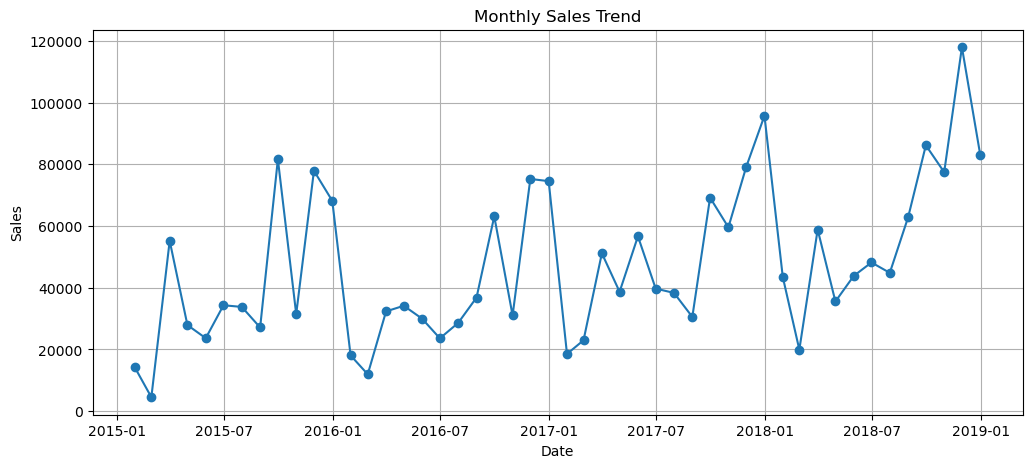

In [15]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig("Charts/monthly_sales_trend.png")

plt.show()

In [16]:
!pip install statsmodels

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [18]:
monthly_series = monthly_sales.set_index("Order Date")["Sales"]

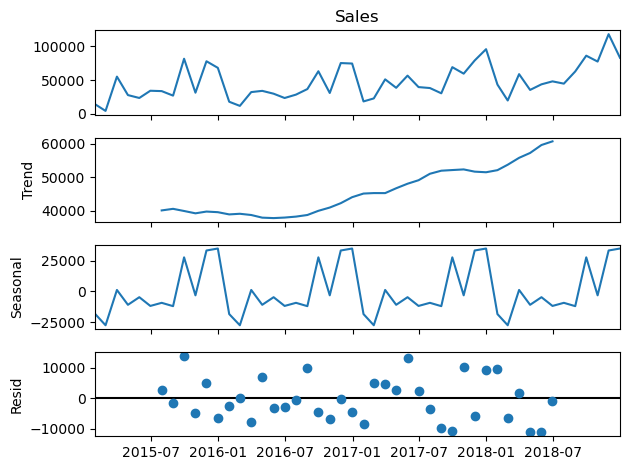

In [19]:
decomposition = seasonal_decompose(
    monthly_series,
    model="additive",
    period=12
)

decomposition.plot()

plt.savefig("Charts/seasonal_decomposition.png")

plt.show()

### Augmented Dickey-Fuller (ADF) Test

In [20]:
from statsmodels.tsa.stattools import adfuller

In [21]:
result = adfuller(monthly_series)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -4.41613676143077
P-value: 0.00027791039276670493


In [22]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is NOT stationary.")

The time series is stationary.


### First Order Differencing

In [23]:
diff_series = monthly_series.diff().dropna()

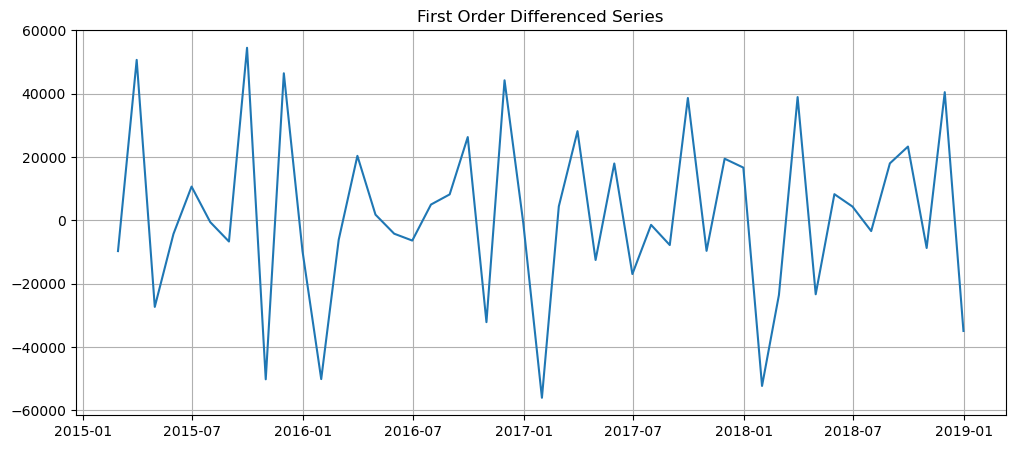

In [24]:
plt.figure(figsize=(12,5))

plt.plot(diff_series)

plt.title("First Order Differenced Series")

plt.grid(True)

plt.savefig("Charts/differenced_series.png")

plt.show()

### Observation

The monthly sales trend shows fluctuations over time with clear seasonal patterns.
Seasonal decomposition separates the trend, seasonal effects, and residual components.
The Augmented Dickey-Fuller test determines whether the time series is stationary.
If required, first-order differencing is applied to stabilize the series before forecasting models are developed.

In [25]:
!pip install prophet
!pip install xgboost
!pip install pmdarima

## Task 3: Forecasting Models

### Model 1: SARIMA

In [26]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
ts = monthly_sales.set_index("Order Date")["Sales"]

In [28]:
train = ts[:-12]
test = ts[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 36
Testing observations: 12


In [29]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=824.086, Time=0.41 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=828.436, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=822.416, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=821.290, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=880.891, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=828.310, Time=0.02 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=822.867, Time=0.06 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=820.150, Time=0.10 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=822.098, Time=0.11 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=820.077, Time=0.07 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=821.190, Time=0.03 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=821.928, Time=0.08 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=822.550, Time=0.05 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=819.738, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[12] intercep

In [30]:
model = SARIMAX(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order
)

sarima = model.fit()

c:\Users\sathv\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sathv\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sathv\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [31]:
forecast = sarima.forecast(steps=12)

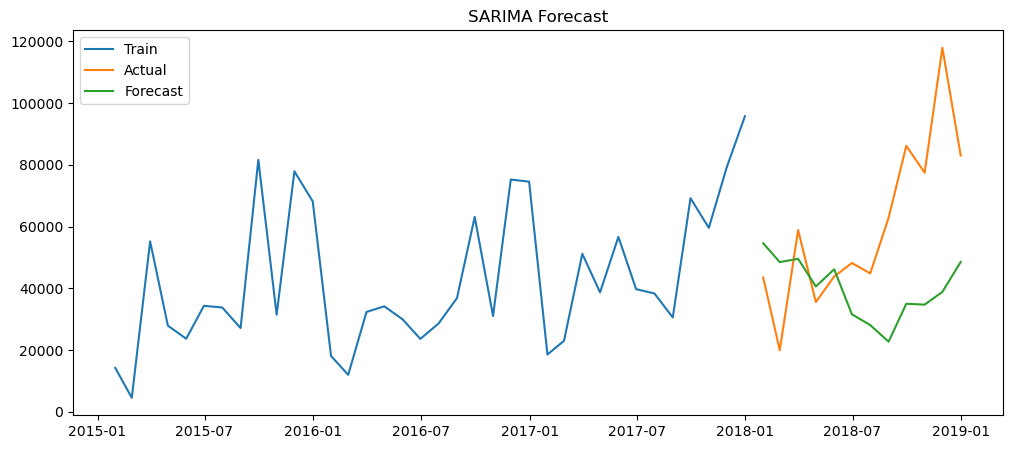

In [32]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("SARIMA Forecast")

plt.legend()

plt.savefig("Charts/sarima_forecast.png")

plt.show()

In [33]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 28114.61
RMSE: 35494.91
MAPE: 46.93 %


### Observation

The SARIMA model captures the seasonal trend in monthly sales and provides a baseline forecasting model. The evaluation metrics (MAE, RMSE, and MAPE) will later be compared with Prophet and XGBoost to identify the best-performing forecasting approach.

### Model 2: Prophet Forecasting

In [34]:
from prophet import Prophet

In [35]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [36]:
train_prophet = prophet_df[:-12]
test_prophet = prophet_df[-12:]

In [37]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

14:17:49 - cmdstanpy - INFO - Chain [1] start processing
14:17:50 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
future = prophet_model.make_future_dataframe(
    periods=12,
    freq="M"
)

c:\Users\sathv\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [39]:
forecast_prophet = prophet_model.predict(future)

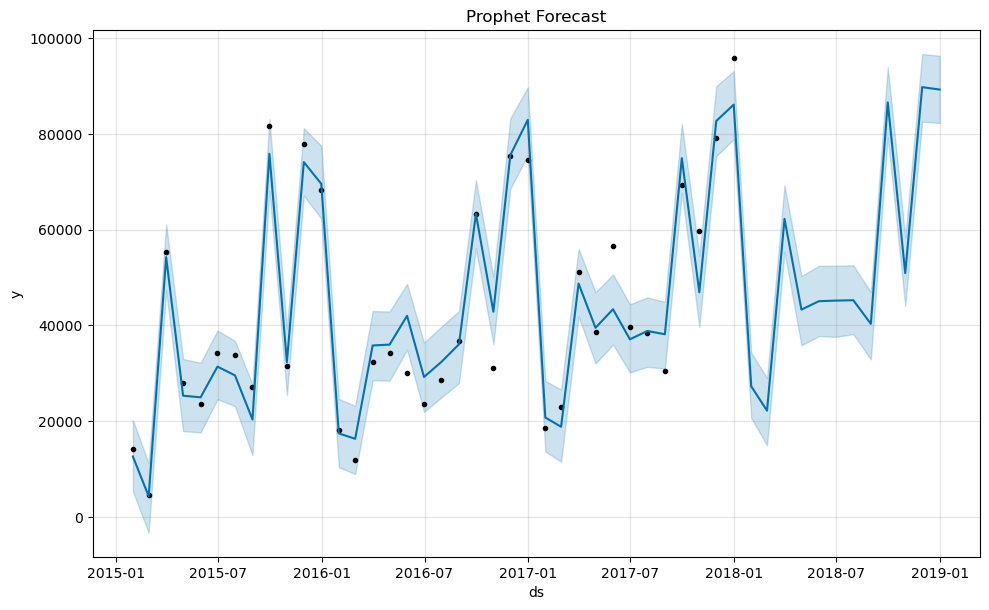

In [40]:
fig = prophet_model.plot(forecast_prophet)

plt.title("Prophet Forecast")

plt.savefig("Charts/prophet_forecast.png")

plt.show()

In [41]:
pred = forecast_prophet["yhat"].tail(12).values

mae_prophet = mean_absolute_error(
    test_prophet["y"],
    pred
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        pred
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_prophet["y"] - pred) /
        test_prophet["y"]
    )
) * 100

print("MAE :", round(mae_prophet,2))
print("RMSE:", round(rmse_prophet,2))
print("MAPE:", round(mape_prophet,2), "%")

MAE : 9839.84
RMSE: 14133.08
MAPE: 15.67 %


### Observation

Prophet automatically models trend and seasonality in the sales data. Its forecasting performance will be compared with SARIMA and XGBoost using MAE, RMSE, and MAPE.

### Model 3: XGBoost Forecasting

In [42]:
from xgboost import XGBRegressor

In [43]:
ml_data = monthly_sales.copy()

ml_data["Lag1"] = ml_data["Sales"].shift(1)
ml_data["Lag2"] = ml_data["Sales"].shift(2)
ml_data["Lag3"] = ml_data["Sales"].shift(3)

ml_data["RollingMean3"] = (
    ml_data["Sales"]
    .rolling(3)
    .mean()
)

ml_data["Month"] = ml_data["Order Date"].dt.month
ml_data["Quarter"] = ml_data["Order Date"].dt.quarter

ml_data = ml_data.dropna()

ml_data.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [44]:
features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean3",
    "Month",
    "Quarter"
]

X = ml_data[features]
y = ml_data["Sales"]

In [45]:
X_train = X[:-12]
X_test = X[-12:]

y_train = y[:-12]
y_test = y[-12:]

In [46]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
xgb_pred = xgb_model.predict(X_test)

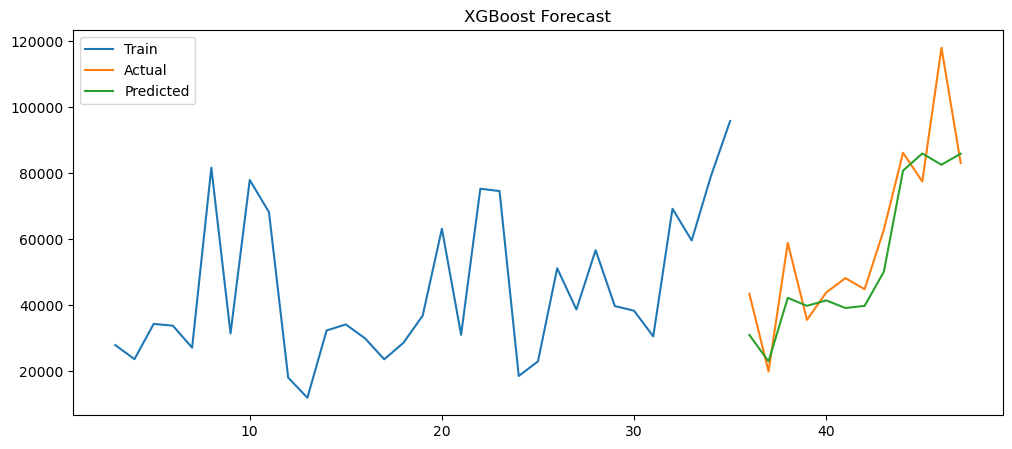

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    y_train.index,
    y_train,
    label="Train"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_pred,
    label="Predicted"
)

plt.title("XGBoost Forecast")

plt.legend()

plt.savefig("Charts/xgboost_forecast.png")

plt.show()

In [49]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

mape_xgb = np.mean(
    np.abs(
        (y_test - xgb_pred) /
        y_test
    )
) * 100

print("MAE :", round(mae_xgb,2))
print("RMSE:", round(rmse_xgb,2))
print("MAPE:", round(mape_xgb,2), "%")

MAE : 9818.17
RMSE: 13230.1
MAPE: 15.89 %


### Observation

The XGBoost model uses lag features and rolling averages to learn temporal patterns in sales. Its performance is evaluated using MAE, RMSE, and MAPE and will be compared with the SARIMA and Prophet models.

## Model Comparison

In [50]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE": [
        mape,
        mape_prophet,
        mape_xgb
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,28114.606333,35494.909135,46.932849
1,Prophet,9839.837362,14133.075502,15.668720
2,XGBoost,9818.170584,13230.100221,15.888900


### Observation

The forecasting models were compared using MAE, RMSE, and MAPE. The model with the lowest error values is considered the most suitable for production use because it provides more accurate sales forecasts.

# Task 4: Product Category & Regional Forecasting

In [51]:
from xgboost import XGBRegressor

def forecast_group(df, column, value):
    
    subset = df[df[column] == value]

    monthly = subset.groupby(
        pd.Grouper(key="Order Date", freq="ME")
    )["Sales"].sum().reset_index()

    if len(monthly) < 15:
        print(f"Not enough data for {value}")
        return

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)
    monthly["RollingMean3"] = monthly["Sales"].rolling(3).mean()
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly = monthly.dropna()

    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    X_train = X[:-12]
    X_test = X[-12:]

    y_train = y[:-12]
    y_test = y[-12:]

    model = XGBRegressor(
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    plt.figure(figsize=(10,4))

    plt.plot(
        y_test.index,
        y_test,
        label="Actual"
    )

    plt.plot(
        y_test.index,
        pred,
        label="Forecast"
    )

    plt.title(value)

    plt.legend()

    plt.savefig(f"Charts/{value}_forecast.png")

    plt.show()

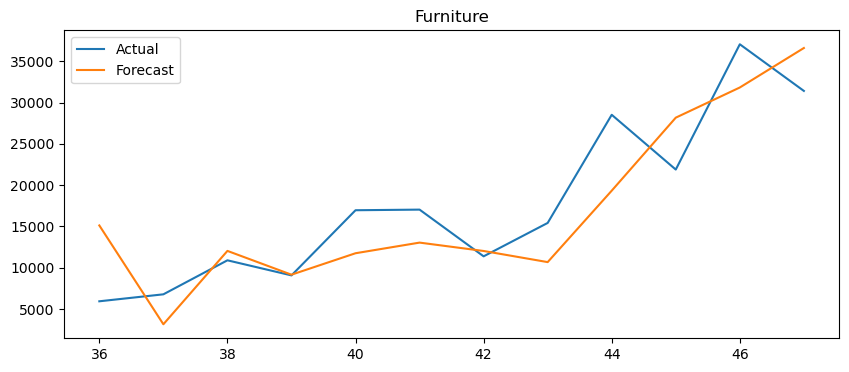

In [52]:
forecast_group(sales, "Category", "Furniture")

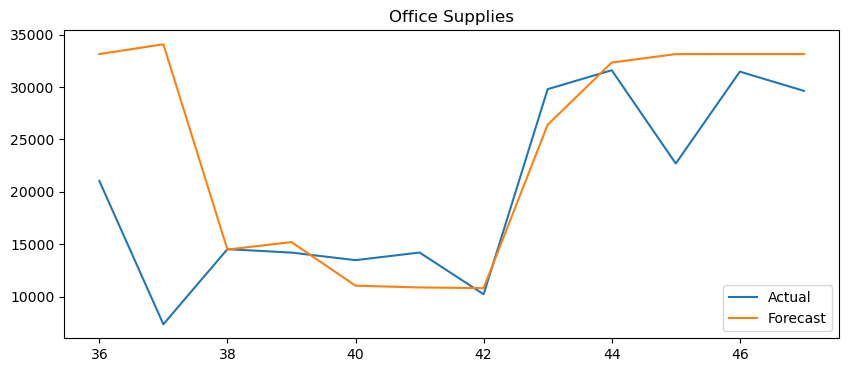

In [53]:
forecast_group(sales, "Category", "Office Supplies")

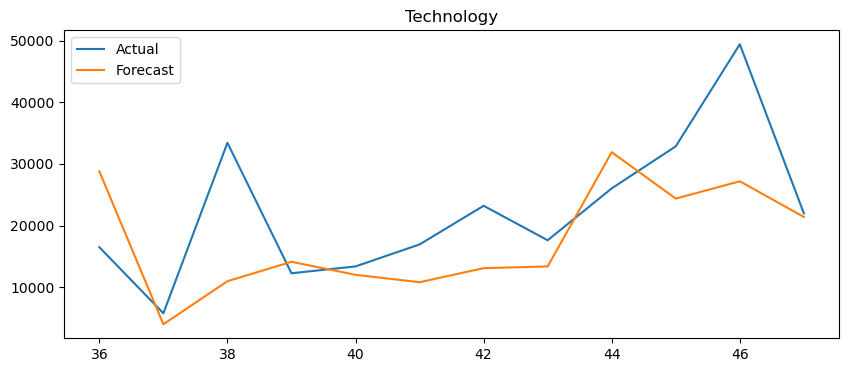

In [54]:
forecast_group(sales, "Category", "Technology")

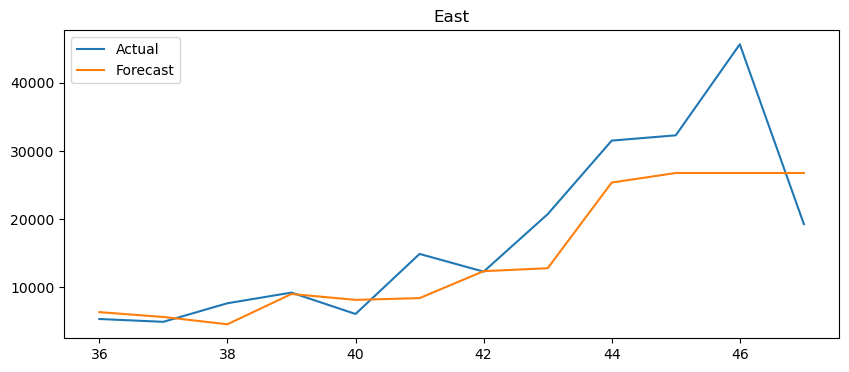

In [55]:
forecast_group(sales, "Region", "East")

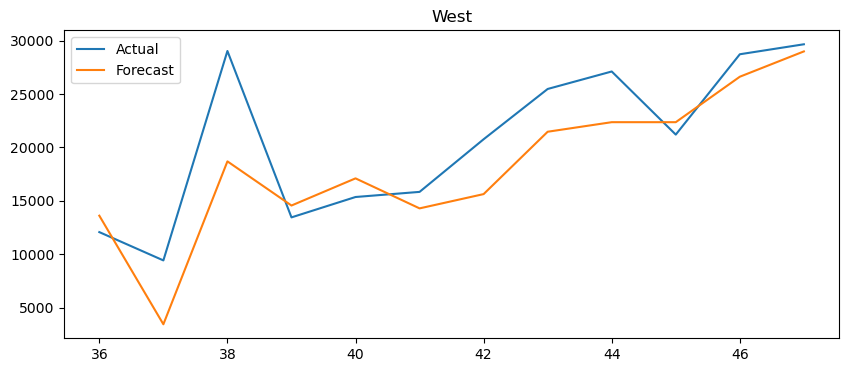

In [56]:
forecast_group(sales, "Region", "West")

### Observation

The XGBoost model was applied to individual product categories and regions. Separate forecasts reveal that different business segments exhibit different sales patterns. These forecasts can help managers plan inventory, marketing, and resource allocation more effectively.

# Task 5: Anomaly Detection

In [57]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [58]:
anomaly_df = sales.copy()

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_df["Anomaly"] = iso.fit_predict(
    anomaly_df[["Sales"]]
)

anomaly_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season,Anomaly
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,1
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,1
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,1
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,1
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,1


In [59]:
print("Normal Records:",
      (anomaly_df["Anomaly"] == 1).sum())

print("Anomalies:",
      (anomaly_df["Anomaly"] == -1).sum())

Normal Records: 9604
Anomalies: 196


In [60]:
anomaly_df["ZScore"] = zscore(
    anomaly_df["Sales"]
)

anomaly_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season,Anomaly,ZScore
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,1,0.049776
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,1,0.799801
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,1,-0.344944
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,1,1.159887
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,1,-0.332580


In [61]:
outliers = anomaly_df[
    abs(anomaly_df["ZScore"]) > 3
]

print("Z-Score Outliers:", len(outliers))

Z-Score Outliers: 123


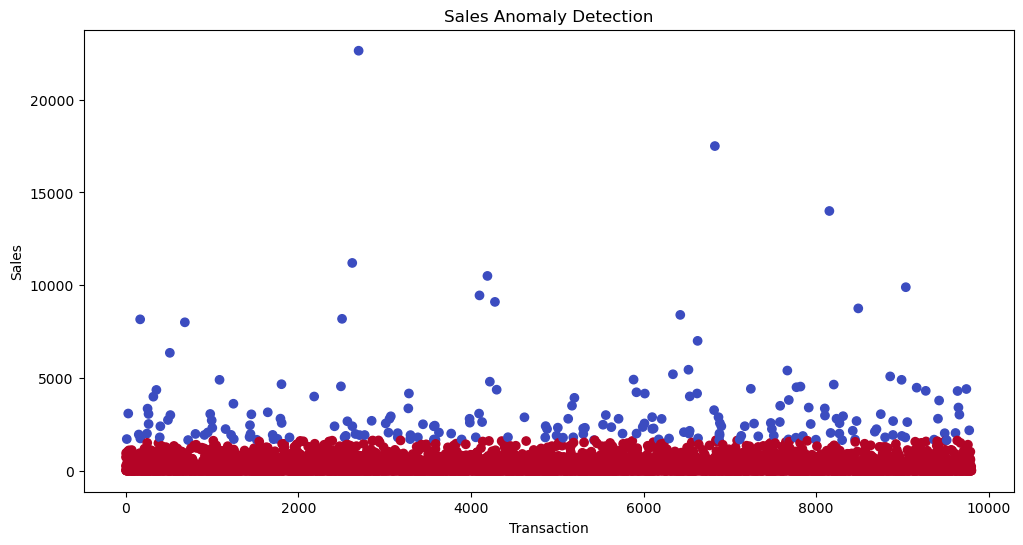

In [62]:
plt.figure(figsize=(12,6))

plt.scatter(
    anomaly_df.index,
    anomaly_df["Sales"],
    c=anomaly_df["Anomaly"],
    cmap="coolwarm"
)

plt.title("Sales Anomaly Detection")

plt.xlabel("Transaction")

plt.ylabel("Sales")

plt.savefig("Charts/anomaly_detection.png")

plt.show()

### Observation

Isolation Forest successfully identified unusual sales transactions that differ significantly from normal purchasing patterns. The Z-score method was also used to detect extreme values. These anomalies can help businesses investigate unusual orders, fraudulent transactions, or exceptional sales events.

# Task 6: Product Demand Segmentation

In [79]:
subcat = sales.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Order_Value=("Sales", "mean")
).reset_index()

subcat.head()

,Sub-Category,Total_Sales,Avg_Order_Value
0,Accessories,164186.7000,217.178175
1,Appliances,104618.4030,227.926804
2,Art,26705.4100,34.019631
3,Binders,200028.7850,134.067550
4,Bookcases,113813.1987,503.598224


In [80]:
monthly = sales.groupby(
    ["Sub-Category", "Year", "Month"]
)["Sales"].sum().reset_index()

monthly.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


In [81]:
volatility = monthly.groupby("Sub-Category")["Sales"].std().reset_index()

volatility.columns = [
    "Sub-Category",
    "Volatility"
]

volatility.head()

,Sub-Category,Volatility
0,Accessories,2579.994809
1,Appliances,1821.621539
2,Art,330.488343
3,Binders,3848.223648
4,Bookcases,2220.405080


In [82]:
yearly = sales.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().reset_index()

yearly.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


In [83]:
growth = yearly.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
).fillna(0)

growth["Growth"] = (
    growth.iloc[:, -1] -
    growth.iloc[:, 0]
) / (growth.iloc[:, 0] + 1)

growth = growth[["Growth"]].reset_index()

growth.head()

Year,Sub-Category,Growth
0,Accessories,1.450499
1,Appliances,1.652320
2,Art,0.496411
3,Binders,0.657771
4,Bookcases,0.498441


In [84]:
cluster_df = subcat.merge(
    volatility,
    on="Sub-Category"
)

cluster_df = cluster_df.merge(
    growth,
    on="Sub-Category"
)

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Volatility,Growth
0,Accessories,164186.7000,217.178175,2579.994809,1.450499
1,Appliances,104618.4030,227.926804,1821.621539,1.652320
2,Art,26705.4100,34.019631,330.488343,0.496411
3,Binders,200028.7850,134.067550,3848.223648,0.657771
4,Bookcases,113813.1987,503.598224,2220.405080,0.498441


In [85]:
from sklearn.preprocessing import StandardScaler

features = [
    "Total_Sales",
    "Avg_Order_Value",
    "Volatility",
    "Growth"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df[features])

c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

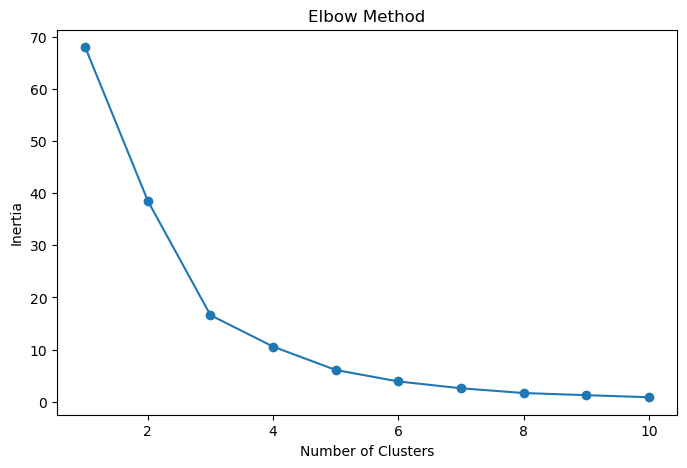

In [86]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_data)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("Charts/elbow_method.png")

plt.show()

In [87]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_df.head()

c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Sub-Category,Total_Sales,Avg_Order_Value,Volatility,Growth,Cluster
0,Accessories,164186.7000,217.178175,2579.994809,1.450499,0
1,Appliances,104618.4030,227.926804,1821.621539,1.652320,2
2,Art,26705.4100,34.019631,330.488343,0.496411,2
3,Binders,200028.7850,134.067550,3848.223648,0.657771,0
4,Bookcases,113813.1987,503.598224,2220.405080,0.498441,2


In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

cluster_df["PC1"] = pca_data[:,0]
cluster_df["PC2"] = pca_data[:,1]

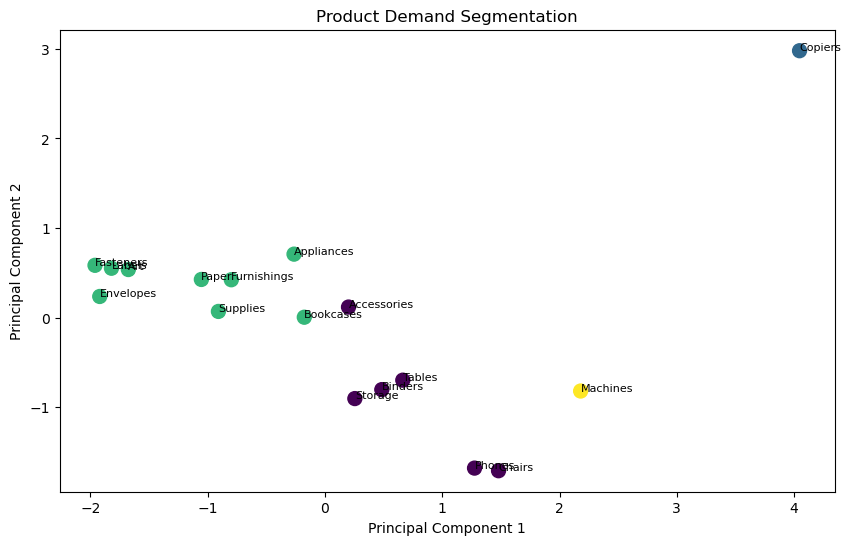

In [89]:
plt.figure(figsize=(10,6))

plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["Cluster"],
    cmap="viridis",
    s=100
)

for i, txt in enumerate(cluster_df["Sub-Category"]):
    plt.annotate(
        txt,
        (
            cluster_df["PC1"].iloc[i],
            cluster_df["PC2"].iloc[i]
        ),
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("Charts/product_clusters.png")

plt.show()

In [90]:
cluster_df.sort_values("Cluster")

,Sub-Category,Total_Sales,Avg_Order_Value,Volatility,Growth,Cluster,PC1,PC2
0,Accessories,164186.7000,217.178175,2579.994809,1.450499,0,0.200404,0.116765
3,Binders,200028.7850,134.067550,3848.223648,0.657771,0,0.484175,-0.805570
5,Chairs,322822.7310,531.833165,4407.232960,0.209544,0,1.479546,-1.711395
14,Storage,219343.3920,263.633885,2822.084310,0.383653,0,0.254390,-0.905556
13,Phones,327782.4480,374.180877,4052.718221,0.355571,0,1.274892,-1.682171
16,Tables,202810.6280,645.893720,3224.082504,0.330773,0,0.663161,-0.700032
6,Copiers,146248.0940,2215.880212,5500.774391,4.796853,1,4.046060,2.979851
2,Art,26705.4100,34.019631,330.488343,0.496411,2,-1.676784,0.535834
7,Envelopes,16128.0460,65.032444,228.218688,-0.121182,2,-1.920700,0.234910
4,Bookcases,113813.1987,503.598224,2220.405080,0.498441,2,-0.176582,0.003198


### Cluster Interpretation

| Cluster | Suggested Label | Business Strategy |
|----------|-----------------|-------------------|
| Cluster 0 | High Volume, Stable Demand | Maintain sufficient inventory and prioritize stock availability. |
| Cluster 1 | Growing Demand | Increase inventory gradually and monitor future sales trends. |
| Cluster 2 | Low Volume, High Volatility | Maintain limited stock and review demand frequently. |
| Cluster 3 | Declining Demand | Reduce inventory levels and consider promotional campaigns to clear stock. |

### Observation

Products were segmented into four demand groups using K-Means clustering based on total sales, average order value, sales volatility, and growth rate. This segmentation helps businesses identify high-performing products, monitor growing product categories, manage volatile demand, and optimize inventory planning.